In [1]:
import sys
import pandas as pd
import csv
import numpy as np
import os
sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from get_data import *
from plotting import *
from get_LrLx_data import *
import plotly.graph_objects as go

# Get Data

In [17]:
source_df, obs_df, radio_df, xray_df = read_data("../DATA/GX 339-4.txt")

GX 339-4
Added 5% systematic uncertainty to the radio data.
X-ray uncertainty percentage:  68
Added 10.0% systematic uncertainty to the X-ray data.


In [4]:
obs_df

,name,xray_CI,xray_obs_ref,radio_obs_ref,extra_xray_text,extra_radio_text
0,GX 339-4,68,[Crook-Mansour et al. (in prep.) &],[Tremou et al. (2020) & https://ui.adsabs.harv...,NaN,The MeerKAT images can be found <a href='https...


In [5]:
source_df

,name,class,l_deg,b_deg,coordinates_refs,D,D_prob,distance_distribution_text,distance_refs
0,GX 339-4,BH,338.939,-4.326,[https://simbad.u-strasbg.fr/simbad/sim-id?Ide...,10.0,"(""uniform"", 8, 12)",8.0-12.0,[https://ui.adsabs.harvard.edu/abs/2019MNRAS.4...


In [6]:
radio_df.head()

,name,blockID,band,t_radio,dt_radio,Rphase,Rstate,Fr,Fr_unc,local_rms,alpha,alpha_unc,Fr_uplim_bool
0,GX 339-4,1523747370,L,58223.01521,0.078762,quiescence,QS,0.05580,0.01860,NaN,NaN,NaN,True
1,GX 339-4,1536428757,L,58369.74759,0.010181,quiescence,QS,0.12030,0.04010,NaN,NaN,NaN,True
2,GX 339-4,1536945357,L,58375.72670,0.010366,quiescence,QS,0.07860,0.02620,NaN,NaN,NaN,True
3,GX 339-4,1537547850,L,58382.69995,0.010181,quiescence,QS,0.07854,0.02618,NaN,NaN,NaN,True
4,GX 339-4,1538151240,L,58389.69665,0.022398,quiescence,QS,0.10590,0.03530,NaN,NaN,NaN,True


In [7]:
xray_df.head(4)

,name,obsID,t_xray,dt_xray,Xphase,Xstate,Fx,Fx_unc_l,Fx_unc_u,model,fit_stat,Fx_uplim_bool
0,GX 339-4,00032898172pc,58227.67730,0.412907,quiescence,QS,9.110000e-13,2.035269e-13,2.279917e-13,pegged_powerlaw,NaN,False
1,GX 339-4,00032898177pc,58396.39485,0.068114,quiescence,QS,8.750000e-13,2.330499e-13,2.714871e-13,pegged_powerlaw,NaN,False
2,GX 339-4,00032898178pc,58403.96213,0.075187,quiescence,QS,9.300000e-13,2.315016e-13,2.658007e-13,pegged_powerlaw,NaN,False
3,GX 339-4,00032898181pc,58423.15508,0.065657,quiescence,QS,2.250000e-12,4.747094e-13,5.656731e-13,pegged_powerlaw,NaN,False


In [16]:
xray_df

,name,obsID,t_xray,dt_xray,Xphase,Xstate,Fx,Fx_unc_l,Fx_unc_u,model,fit_stat,Fx_uplim_bool
0,GX 339-4,00032898172pc,58227.67730,0.412907,quiescence,QS,9.110000e-13,2.035269e-13,2.279917e-13,pegged_powerlaw,NaN,False
1,GX 339-4,00032898177pc,58396.39485,0.068114,quiescence,QS,8.750000e-13,2.330499e-13,2.714871e-13,pegged_powerlaw,NaN,False
2,GX 339-4,00032898178pc,58403.96213,0.075187,quiescence,QS,9.300000e-13,2.315016e-13,2.658007e-13,pegged_powerlaw,NaN,False
3,GX 339-4,00032898181pc,58423.15508,0.065657,quiescence,QS,2.250000e-12,4.747094e-13,5.656731e-13,pegged_powerlaw,NaN,False
4,GX 339-4,00032898182wt,58504.07539,0.011224,decay,HS,7.420000e-10,7.508588e-11,7.511678e-11,pegged_powerlaw,NaN,False
5,GX 339-4,00032898183wt,58505.63235,0.075803,decay,HS,6.390000e-10,6.602098e-11,6.612269e-11,pegged_powerlaw,NaN,False
6,GX 339-4,00032898183pc,58505.63366,0.077987,decay,HS,6.560000e-10,7.497366e-11,7.596216e-11,pegged_powerlaw,NaN,False
7,GX 339-4,00032898184wt,58507.13413,0.007515,decay,HS,7.310000e-10,7.439120e-11,7.444743e-11,pegged_powerlaw,NaN,False
8,GX 339-4,00032898185wt,58510.78994,0.011275,decay,HS,6.950000e-10,7.036512e-11,7.039666e-11,pegged_powerlaw,NaN,False
9,GX 339-4,00032898186wt,58512.25295,0.014347,decay,HS,7.250000e-10,7.320014e-11,7.321400e-11,pegged_powerlaw,NaN,False


# Light Curves

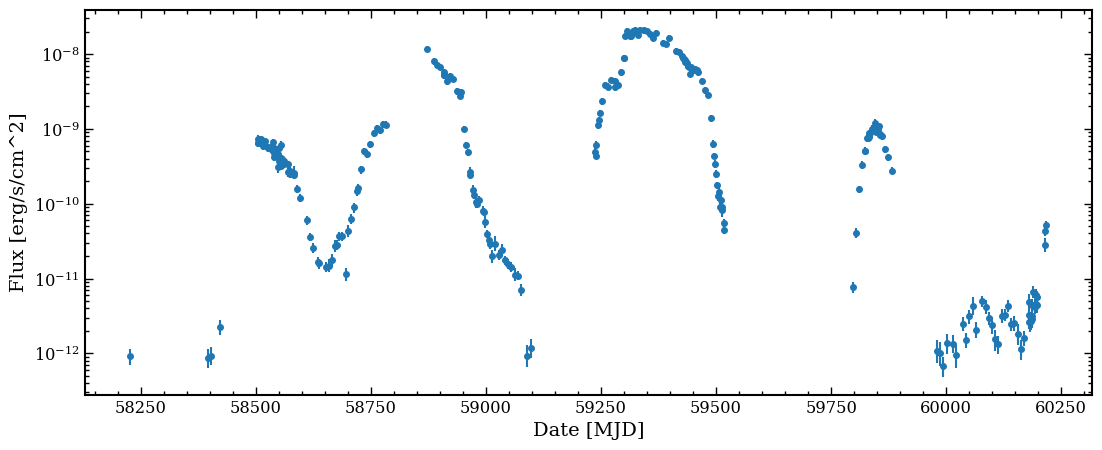

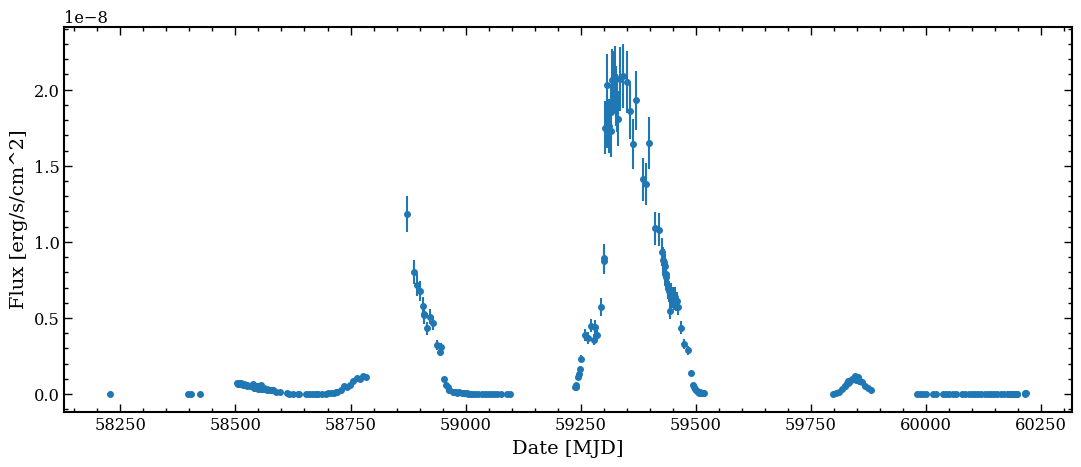

In [8]:
# WITH systematic errors
plot_xray_lightcurve(xray_df)

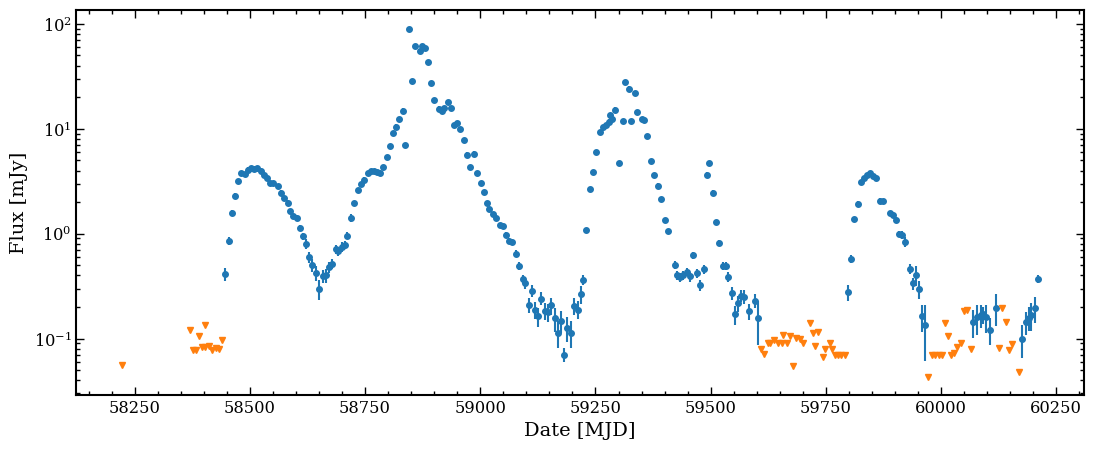

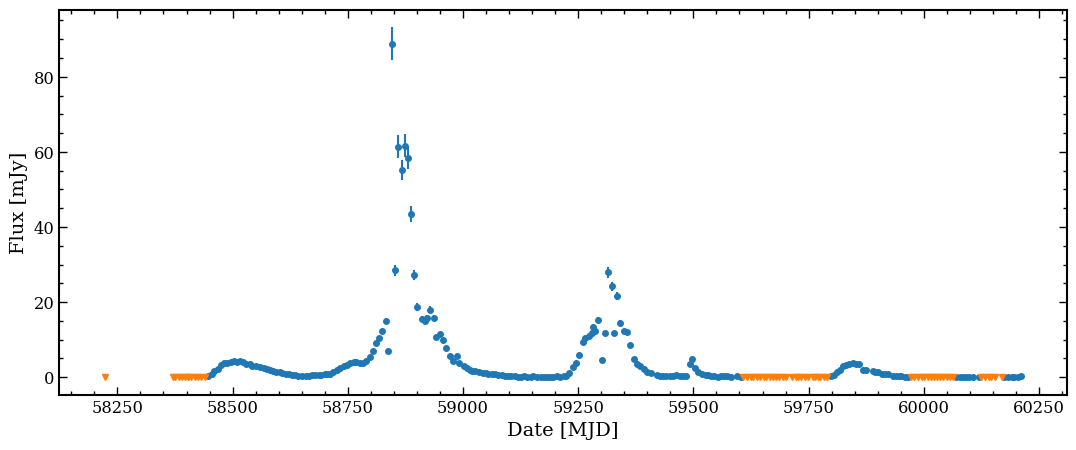

In [9]:
# WITH systematic error
plot_radio_lightcurve(radio_df)

In [10]:
len(radio_df)

261

# Pairing

In [18]:
paired_data = make_paired_Lr_Lx_df(radio_df, xray_df, source_df)

t_radio             Fr [mJy]            Fr_unc [mJy]        #xray     t_diff                        Mean Fx [erg/cm^2/s]          Fx_unc_l[erg/cm^2/s]          Fx_unc_u[erg/cm^2/s]          Fr_uplim_bool  Fx_uplim_bool  state          
58396.642200000     0.08319             0.02773             1         [0.247]                       8.75000e-13                   2.33050e-13                   2.71487e-13                   True           False          QS             
58403.619100000     0.13440             0.04480             1         [0.343]                       9.30000e-13                   2.31502e-13                   2.65801e-13                   True           False          QS             
58537.119450000     3.42000             0.17966             2         [0.501 0.502]                 6.12802e-10                   4.55078e-11                   4.56787e-11                   False          False          HS             
58543.104060000     3.03000             0.15951         

In [19]:
len(paired_data)

86

In [13]:
lr_all, lx_all, all_types = get_bahramian_data()

Only including detections from Bahramian et al. data.
Converting Bahramian Lr values from 5 GHz to 1.28 GHz, assuming flat spectral index.


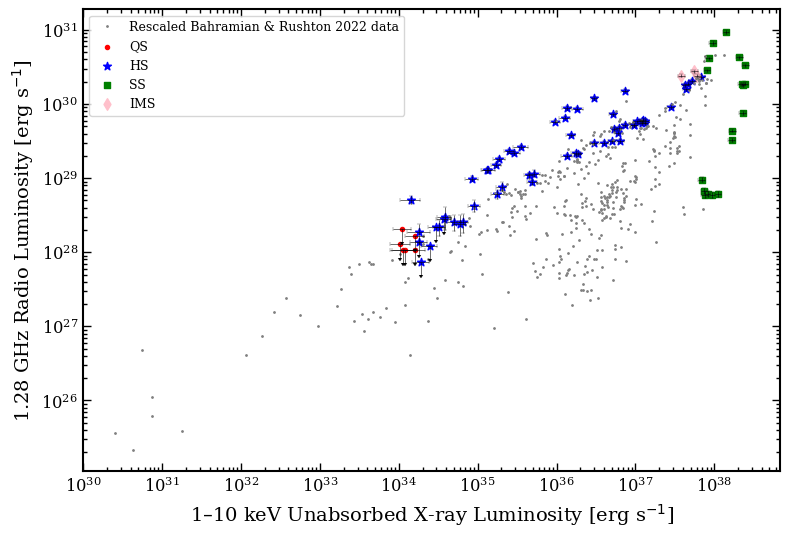

In [14]:
plot_Lr_Lx(paired_data, colourby="state", lx=lx_all, lr=lr_all)

In [37]:
#paired_data[["t", "Lr","Fr", "Fr_unc", "Lx"]].sort_values(by="Lx")
#paired_data[["t", "Lr","Fr", "Lx", "Fx"]].sort_values(by="t")

# Interpolation

dt1, dt2:  3.0 10.0

Number of plotting points:  3978
Rejected based on distance: radio_MJD = 58223.01521; time_to_nearest: 4.662090000005264; time_to_furthest: 58223.01521
Rejected based on distance: radio_MJD = 58369.74759; time_to_nearest: 26.647259999997914; time_to_furthest: 142.07028999999602
Rejected based on distance: radio_MJD = 58375.7267; time_to_nearest: 20.668149999997695; time_to_furthest: 148.04939999999624
Rejected based on distance: radio_MJD = 58382.69995; time_to_nearest: 13.69489999999496; time_to_furthest: 155.02264999999898
Rejected based on distance: radio_MJD = 58389.69665; time_to_nearest: 6.698199999998906; time_to_furthest: 162.01934999999503
58396.6422: time_to_nearest: 0.247350000005099 & time_to_furthest: 7.319929999997839; y_predict_err: 0.12885188401855174
58402.68382: time_to_nearest: 1.278310000001511 & time_to_furthest: 6.288970000001427; y_predict_err: 0.12261752118726044
58403.6191: time_to_nearest: 0.34302999999636086 & time_to_furthest: 7.22425000

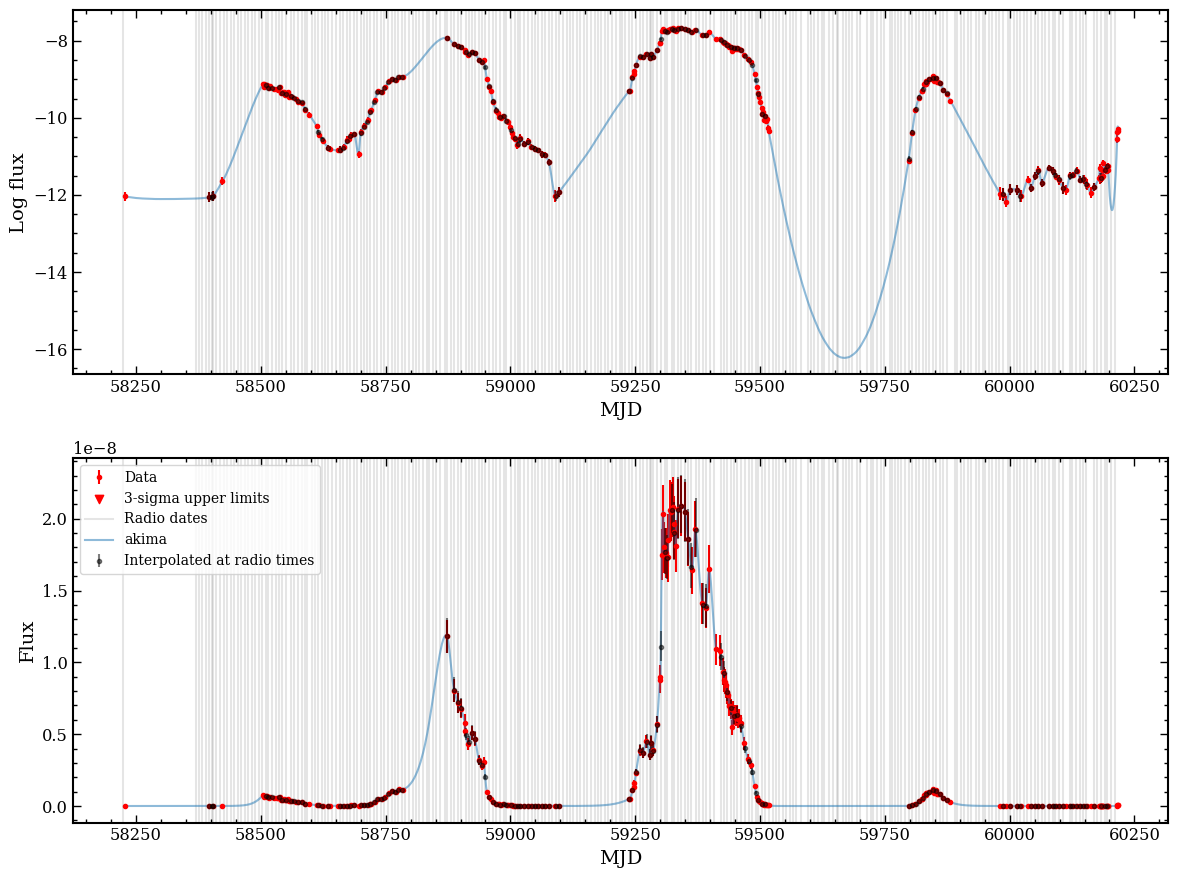

Number of used interpolated data points:  138
Converting to luminosity using d_kpc = 10.0


In [20]:
interpolated_data = make_interpolated_Lr_Lx_df(radio_df, xray_df, source_df, plotly=True)

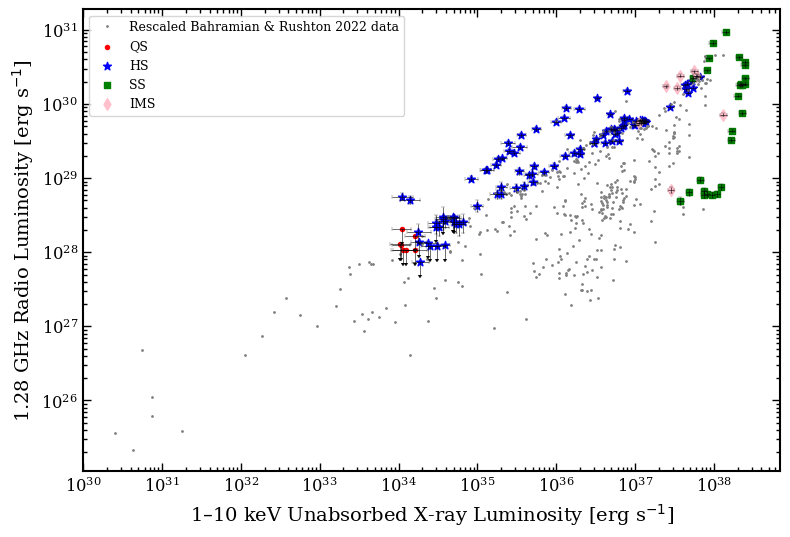

In [21]:
plot_Lr_Lx(interpolated_data, colourby="state", lx=lx_all, lr=lr_all)

In [22]:
plot_Lr_Lx_plotly(interpolated_data, colourby="state")

---

# Time Evolution

In [19]:
plot_time_evolution_timed(paired_data)

---

# NICER Dates

In [ ]:
## Get NICER observation dates

csv_file_path = '../DATA/NICER/GX 339-4_NICER_dates.csv'

# Initialize a list to hold time values
time_values = []

# Read the CSV file
with open(csv_file_path, 'r', newline='') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # Clean the string: remove quotes and replace comma with dot
        time_str = row['time'].strip('"').replace(',', '.')
        time_values.append(float(time_str))

# Convert to NumPy array
nicer_dates = np.array(time_values)

In [23]:
## Get radio and Swift/XRT observation dates and states
radio_dates = radio_df["t_radio"].to_numpy()
radio_states = radio_df["Rstate"].to_numpy()
swift_dates = xray_df["t_xray"].to_numpy()


## Rough dates for the state transitions
transitions = [58835, 58920, 58950, 59295, 59310, 59480, 59492]

In [27]:
# Create the figure
fig = go.Figure()

# Add scatter plots
fig.add_trace(go.Scatter(
    x=radio_dates, y=[1]*len(radio_dates),
    mode='markers',
    marker=dict(color='red', size=3),
    name='Radio'
))

fig.add_trace(go.Scatter(
    x=swift_dates, y=[2]*len(swift_dates),
    mode='markers',
    marker=dict(color='blue', size=3),
    name='Swift/XRT'
))

fig.add_trace(go.Scatter(
    x=nicer_dates, y=[3]*len(nicer_dates),
    mode='markers',
    marker=dict(color='green', size=3),
    name='NICER'
))

# Add vertical dotted lines for transitions
for t in transitions:
    fig.add_shape(
        type='line',
        x0=t, x1=t, y0=0.5, y1=3.5,
        line=dict(color='black', width=1, dash='dot'),
        name='Transition'
    )

# Update layout
fig.update_layout(
    xaxis_title='MJD',
    xaxis=dict(
        title='Time',
        tickformat='.d',  # Ensure no scientific notation or suffixes
        tickmode='auto'
    ),
    yaxis=dict(
        tickvals=[1, 2, 3],
        ticktext=['Radio', 'Swift/XRT', 'NICER'],
        title='Observation Type'
    ),
    showlegend=True,
    height=700
)

# Show the plot
fig.show()

In [29]:
# How many additional points would I get by including NICER data?


## Define binning function
def get_paired_flags(radio_dates, xray_dates, window_days=1.0):
    flags = np.array([
        np.any(np.abs(xray_dates - rd) <= window_days)
        for rd in radio_dates
    ])
    return flags

## Pairing check for all radio_dates
paired_nicer = get_paired_flags(radio_dates, nicer_dates)
paired_swift = get_paired_flags(radio_dates, swift_dates)

## Find how many nicer-paired are not swift-paired
exclusive_nicer = paired_nicer & ~paired_swift
num_exclusive_nicer = np.sum(exclusive_nicer)

## Repeat for subset where state is "HS" or "QS"
hs_qs_mask = np.isin(radio_states, ["HS", "QS"])

## Apply mask
radio_dates_hs_qs = radio_dates[hs_qs_mask]
nicer_paired_hs_qs = get_paired_flags(radio_dates_hs_qs, nicer_dates)
swift_paired_hs_qs = get_paired_flags(radio_dates_hs_qs, swift_dates)
exclusive_nicer_hs_qs = nicer_paired_hs_qs & ~swift_paired_hs_qs
num_exclusive_nicer_hs_qs = np.sum(exclusive_nicer_hs_qs)

## Final outputs
print("Total radio dates:", len(radio_dates))
print("Paired with NICER:", np.sum(paired_nicer))
print("Paired with Swift/XRT:", np.sum(paired_swift))
print("NICER-only paired (not in Swift):", num_exclusive_nicer)

print("\nSubset (state in ['HS', 'QS']):")
print("Total:", len(radio_dates_hs_qs))
print("Paired with NICER:", np.sum(nicer_paired_hs_qs))
print("Paired with Swift/XRT:", np.sum(swift_paired_hs_qs))
print("NICER-only paired (not in Swift/XRT):", num_exclusive_nicer_hs_qs)

Total radio dates: 259
Paired with NICER: 52
Paired with Swift/XRT: 101
NICER-only paired (not in Swift): 21

Subset (state in ['HS', 'QS']):
Total: 214
Paired with NICER: 28
Paired with Swift/XRT: 79
NICER-only paired (not in Swift/XRT): 8
